In [1]:
import pandas as pd
import numpy as np
sudan=pd.read_csv("../data/sudan.csv",skipfooter=10)
sudan.head()

/tmp/ipykernel_57823/2861132085.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  sudan=pd.read_csv("../data/sudan.csv",skipfooter=10)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [2]:
# missing value
sudan.replace(-999,np.nan,inplace=True)
print(f" Messing Value found:\n {sudan.isnull().sum()}")

 Messing Value found:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [3]:
# date conversion
sudan["DATE"]=pd.to_datetime(sudan["YEAR"]*1000+sudan["DOY"],format= "%Y%j")
sudan["MONTH"]=sudan["DATE"].dt.month
sudan.set_index("DATE",inplace=True)
sudan.head()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,MONTH
DATE,,,,,,,,,,,,,
2015-01-01,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,1
2015-01-02,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,1
2015-01-03,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,1
2015-01-04,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,1
2015-01-05,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,1


In [5]:
# Save cleaned data
sudan.to_csv('../data/sudan_clean.csv', index=False)
print(" Cleaned data saved to: data/sudan_clean.csv")

 Cleaned data saved to: data/sudan_clean.csv


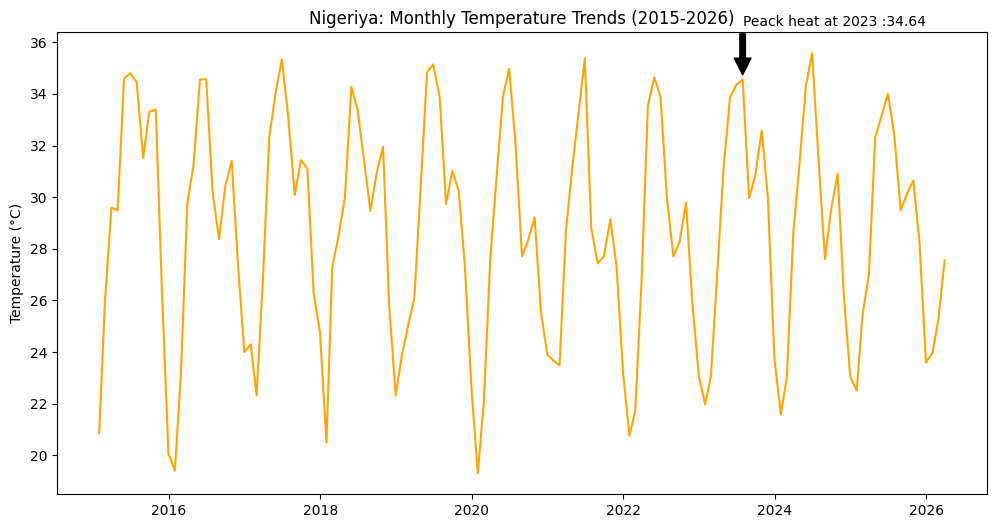

In [4]:
# Monthly Temperature Line Chart
import matplotlib.pyplot as plt
# resample monthely averagy
monthly_temp=sudan["T2M"].resample('ME').mean()
plt.figure(figsize=(12,6))
plt.plot(monthly_temp,label="Mean Temp ",color='orange')
# annotate the hotest month in 2023
hottest_2023=monthly_temp["2023"].idxmax()
temp_max=monthly_temp['2022'].max()
plt.annotate(f"Peack heat at 2023 :{temp_max:.2f}",
             xy=(hottest_2023,temp_max),
             xytext=(hottest_2023,temp_max+2),
             arrowprops=dict(facecolor='black',shrink=0.05))
plt.title('Nigeriya: Monthly Temperature Trends (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.show()


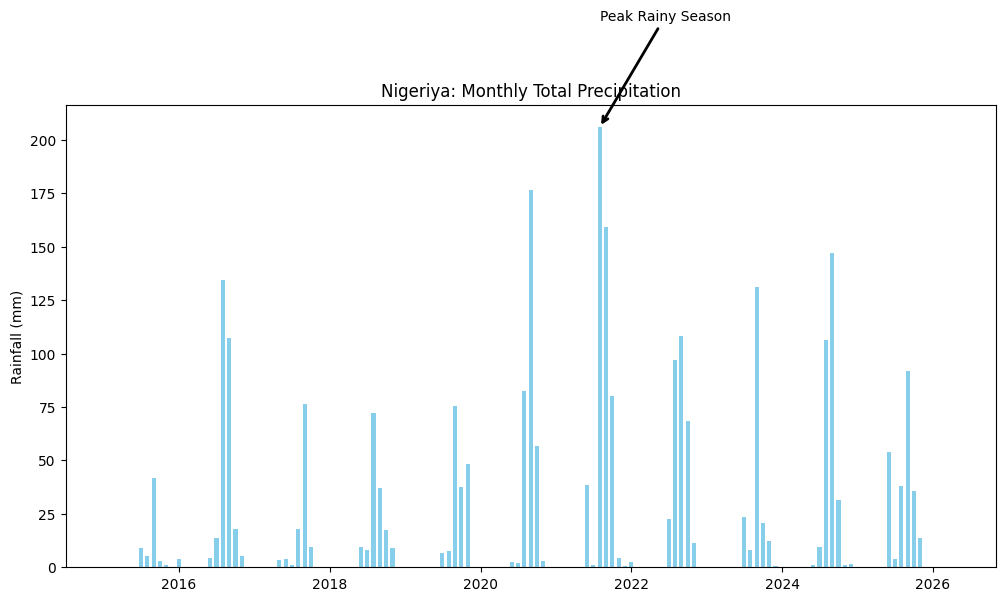

In [ ]:
# Resample to Monthly total rainfall
monthly_rain = sudan['PRECTOTCORR'].resample('ME').sum()

plt.figure(figsize=(12, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='skyblue', width=20) # type: ignore

# Identify the peak rainy season (example: finding the highest bar)
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.annotate('Peak Rainy Season', 
             xy=(peak_month, peak_value),  # type: ignore
             xytext=(peak_month, peak_value + 50), # type: ignore
             arrowprops=dict(arrowstyle='->', lw=2))

plt.title('Nigeriya: Monthly Total Precipitation')
plt.ylabel('Rainfall (mm)')
plt.show()